In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("../dataset/raw/code_quality.csv")

df.head()

,LOC,CyclomaticComplexity,Methods,Classes,CBO,LCOM,DIT,RFC,NOC,WMC,CommentRatio,MaintainabilityIndex,Quality
0,248,2,48,9,7,28,3,193,1,87,0.37,83,Good
1,198,38,28,2,0,11,4,64,8,78,0.01,45,Poor
2,1136,27,15,15,18,35,1,199,2,90,0.21,34,Poor
3,338,14,49,11,3,11,7,29,5,45,0.30,79,Good
4,960,35,8,13,2,70,5,165,9,47,0.29,46,Poor


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 3000
Columns : 13


In [5]:
df.columns

Index(['LOC', 'CyclomaticComplexity', 'Methods', 'Classes', 'CBO', 'LCOM',
       'DIT', 'RFC', 'NOC', 'WMC', 'CommentRatio', 'MaintainabilityIndex',
       'Quality'],
      dtype='object')

In [6]:
df.dtypes

LOC                       int64
CyclomaticComplexity      int64
Methods                   int64
Classes                   int64
CBO                       int64
LCOM                      int64
DIT                       int64
RFC                       int64
NOC                       int64
WMC                       int64
CommentRatio            float64
MaintainabilityIndex      int64
Quality                  object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   LOC                   3000 non-null   int64  
 1   CyclomaticComplexity  3000 non-null   int64  
 2   Methods               3000 non-null   int64  
 3   Classes               3000 non-null   int64  
 4   CBO                   3000 non-null   int64  
 5   LCOM                  3000 non-null   int64  
 6   DIT                   3000 non-null   int64  
 7   RFC                   3000 non-null   int64  
 8   NOC                   3000 non-null   int64  
 9   WMC                   3000 non-null   int64  
 10  CommentRatio          3000 non-null   float64
 11  MaintainabilityIndex  3000 non-null   int64  
 12  Quality               3000 non-null   object 
dtypes: float64(1), int64(11), object(1)
memory usage: 304.8+ KB


In [8]:
df.describe()

,LOC,CyclomaticComplexity,Methods,Classes,CBO,LCOM,DIT,RFC,NOC,WMC,CommentRatio,MaintainabilityIndex
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,608.039333,25.475667,30.516000,10.322667,9.834333,49.82200,4.515667,101.31900,5.044667,51.173667,0.246317,51.922333
std,344.471964,14.485326,17.320308,5.779650,6.012010,28.92731,2.282285,56.55151,3.128674,29.105862,0.142908,18.454136
min,20.000000,1.000000,1.000000,1.000000,0.000000,0.00000,1.000000,5.00000,0.000000,1.000000,0.000000,5.000000
25%,299.000000,12.000000,16.000000,5.000000,5.000000,25.00000,3.000000,52.00000,2.000000,26.000000,0.120000,39.000000
50%,613.500000,26.000000,31.000000,10.000000,10.000000,49.00000,5.000000,101.00000,5.000000,51.000000,0.240000,51.000000
75%,910.000000,38.000000,45.000000,15.000000,15.000000,74.00000,7.000000,151.00000,8.000000,77.000000,0.370000,65.000000
max,1200.000000,50.000000,60.000000,20.000000,20.000000,100.00000,8.000000,200.00000,10.000000,100.000000,0.500000,100.000000


In [9]:
df.isnull().sum()

LOC                     0
CyclomaticComplexity    0
Methods                 0
Classes                 0
CBO                     0
LCOM                    0
DIT                     0
RFC                     0
NOC                     0
WMC                     0
CommentRatio            0
MaintainabilityIndex    0
Quality                 0
dtype: int64

In [10]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [11]:
df["Quality"].value_counts()

Quality
Poor       1406
Average    1221
Good        373
Name: count, dtype: int64

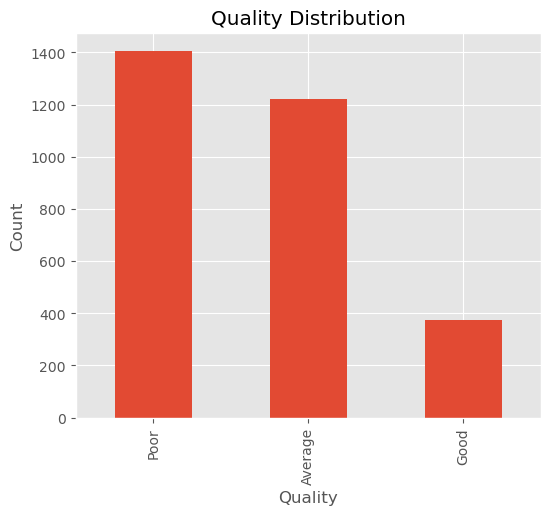

In [12]:
df["Quality"].value_counts().plot(kind="bar", figsize=(6,5))

plt.title("Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")

plt.show()

In [13]:
correlation = df.drop("Quality", axis=1).corr()

correlation

,LOC,CyclomaticComplexity,Methods,Classes,CBO,LCOM,DIT,RFC,NOC,WMC,CommentRatio,MaintainabilityIndex
LOC,1.000000,-0.024842,-0.009335,-0.011838,0.021470,-0.008287,0.011759,0.032451,-0.012740,0.025750,-0.035553,-0.010021
CyclomaticComplexity,-0.024842,1.000000,0.027971,0.000628,-0.011026,-0.001244,-0.001330,0.016588,0.019772,0.000759,0.028393,-0.689121
Methods,-0.009335,0.027971,1.000000,0.022053,0.002823,0.021970,-0.002170,0.002965,-0.048760,-0.013951,-0.004086,-0.025889
Classes,-0.011838,0.000628,0.022053,1.000000,-0.015399,0.003216,0.029521,-0.006370,-0.011861,0.007207,-0.012125,-0.002344
CBO,0.021470,-0.011026,0.002823,-0.015399,1.000000,-0.014026,0.015268,0.004454,0.006563,0.000588,-0.010335,-0.379792
LCOM,-0.008287,-0.001244,0.021970,0.003216,-0.014026,1.000000,0.014825,-0.018432,-0.016477,0.010846,-0.014490,-0.387661
DIT,0.011759,-0.001330,-0.002170,0.029521,0.015268,0.014825,1.000000,0.001352,-0.008737,-0.010921,-0.022228,-0.012587
RFC,0.032451,0.016588,0.002965,-0.006370,0.004454,-0.018432,0.001352,1.000000,-0.002039,0.015920,0.024104,0.000765
NOC,-0.012740,0.019772,-0.048760,-0.011861,0.006563,-0.016477,-0.008737,-0.002039,1.000000,-0.014216,0.008646,-0.005611
WMC,0.025750,0.000759,-0.013951,0.007207,0.000588,0.010846,-0.010921,0.015920,-0.014216,1.000000,0.029991,-0.311731


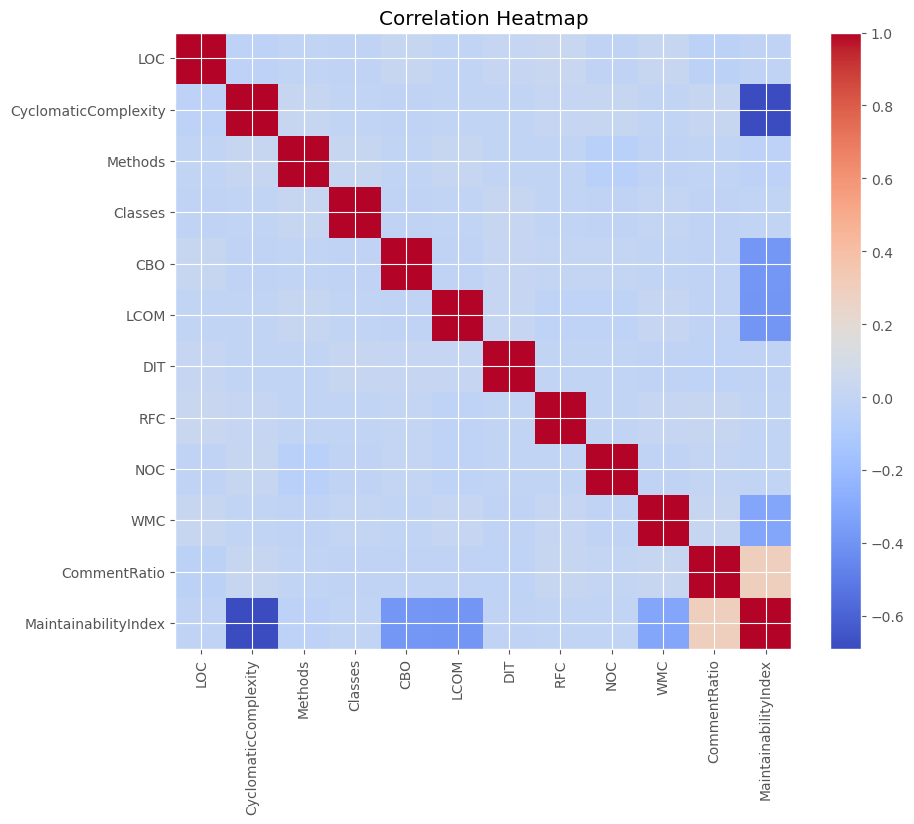

In [14]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [15]:
print("""
Dataset Successfully Loaded

No Missing Values Found

No Duplicate Rows Found

Dataset Ready For Preprocessing
""")


Dataset Successfully Loaded

No Missing Values Found

No Duplicate Rows Found

Dataset Ready For Preprocessing

